
<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Tarea 1: Investigación de HDBSCAN y OPTICS</h1>
<br style="clear:both"/>
</div>


**1.** Realice una investigación sobre los algoritmos HDBSCAN y OPTICS. Explique sus fundamentos, parámetros, funcionamiento, ventajas y limitaciones, e incluya imágenes, diagramas y ejemplos que faciliten su comprensión.


## **HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise)**

### Descripción y Fundamentos
Algoritmo de clustering basado en densidad, se busca **agrupar observaciones o puntos de zonas o regiones con alta concentración de datos** denominandose cluster, las **observaciones que no se agrupan** porque están **alejadas o aisladas** se consideran **ruido**, pues no pertenecen a ningún grupo.

Considera una estructura jerárquica de agrupaciones con diferentes densidades; con aplicación de métricas y parámetros se pueden identificar las agrupaciones más estables.

**HDBSCAN es una extensión de DBSCAN**

### Funcionalidad
Datos **->** Analiza Densidad **->** Construye Jerarquia **->** Identifica Clusters Estables **->** Clasifica Ruido

### Parámetros (principales)

* **min_cluster_size**: número mínimo de observaciones que debe tener un cluster. Al aumentar el valor;se requieren agrupaciones más grandes, se disminuye la identificación de agrupaciones más pequeñas y pueden aumentar los puntos "ruido". Al disminuir el valor; se identifican más los grupos pequeños, se generan más grupos y se dispersa los resultados.

* **min_samples:** controla la identificaión de las observacione a las zonas densas. Un valor mayor crea un algoritmo más conservador.

* **metric:** la metrica calcula la distancia entre observaciones, la más representativa es la 'euclidiana'.

* **eps**: radio máximo para considerar dos puntos vecinos.

### Atributos (principales):
1. **labels_**: etiquetas de cluster para cada punto en el conjunto de datos.
2. **probabilities_**: fuerza con la que cada muestra pertenece al grupo que ha sido asignado.
3. **n_features_in**: número de características observadas durante el entrenamiento.

### Ventajas

1. No requiere quse se le indique el número de clusters.
2. Detecta ruido, observaciones atípicas.
3. Encuentra cluster de diferentes densidades.
4. No requiere un radio -eps- como dbscan.
5. Puede valorarse la estabilidad en los cluster.

### Desventajas
1. Puede generar demasiado ruido.
2. Sensible a los parámetros.
3. Es un poco más difícil de interpretar, utiliza concepto de densidad, jerarquía y estabilidad.

In [5]:
#Ejemplo: aplicado al conjunto de datos 'digits' de scikit-learn
import numpy as np
from sklearn.cluster import HDBSCAN
from sklearn.datasets import load_digits
X, _ = load_digits(return_X_y=True) #Contiene las características de las imágenes.
hdb = HDBSCAN(copy=True, min_cluster_size=20) #Indica que un cluster debe tener al menos 20 observaciones para ser considerado un grupo.
hdb.fit(X)
hdb.labels_.shape == (X.shape[0],)
np.unique(hdb.labels_).tolist()

[-1, 0, 1, 2, 3, 4, 5, 6, 7]

El ejemplo indica que del conjunto de datos 'digit' genero 8 cluster del 0 - 7 y -1 = ruido.

## **OPTICS (Ordering Points To Identify the Clustering Structure)**


### Descripción y Fundamentos
**Algoritmo de clustering basado en densidad**, **identifica la estructura de densidad de datos** sin depender de un único valor de eps (epsilon). Determina **qué tan densa es la conexión entre las observaciones**.

Para ello, genera un ordenamiento de las observaciones y calcula los valores relacionados con la densidad.

Uno de los conceptos que se registara es **Reachability distane** distancia de alcanzabilidad, indica qué tan difícil es llegar desde un punto a otro considerando la densidad de la zona o región.

### Parámetros (pincipales)

* **min_samples**; int > 1 or float between 0 and 1, default=5. Indica el númer mínimo de muestra utilizado para determinar la densidad local. Un valor mayor, exige más al algoritmo con respecto a la densidad.
* **max_eps**; float, default=np.inf. Es la distancia máxima que se considera para buscar vecinos.
* **metric**; str or callable, default=’minkowski’. Métrica de distancia, la más representativa es la 'euclidiana'.
* **cluster_method**; {‘xi’, ‘dbscan’}, default=’xi’. Define como se extraen los clusters a partir de la estructura encontrada. El método 'xi' identifica cambios importantes en la estructura de alcanzabilidad para separar clusters.
* **min_cluster_size**: int > 1 or float between 0 and 1, default=None. Mínimo número de ejemplares en un cluster.
* **xi**:float between 0 and 1, default=0.05. Determina la pendiente mínima en el gráfico de alcanzabilidad que constituye el límite de un clúster.




### Atributos (principales)

1. labels_: ndarray of shape (n_samples,). Etiquetas de clúster para cada punto en el conjunto de datos proporcionado a fit().
2. reachability_: ndarray of shape (n_samples,). Distancias de accesibilidad por muestra, indexadas por orden de objeto.
3. ordering_ndarray of shape (n_samples,). La lista de índices de muestra ordenados por clúster.
4. n_features_: in_int. Número de características observadas durante el entrenamiento.

### Funcionalidad

Datos **->** Calcula densidad local **->** Ordena las observaciones **->** Calcula distancias de alcanzabilidad **->** Construye estructura de densidad **->**
Extrae clusters **->** Identifica ruido

### Ventajas
1. No necesita definir directamente el número de clusters.
2. Maneja diferente densdidades.
3. No depende de un punico eps.
4. Permite visualizar la estructura.

### Desventajas
1. Díficil de interpretar.
2. Depende de sus parámetros.
3. Puede generar mucho ruido.

In [6]:
#Ejemplo: aplicando scikit-learn
from sklearn.cluster import OPTICS
import numpy as np
# se tienen 6 observaciones y dos característica (6 registro, 2 columnas)
X = np.array([[1, 2], [2, 5], [3, 6],
              [8, 7], [8, 8], [7, 3]])
clustering = OPTICS(min_samples=2).fit(X) #indica que se utiliza un mínimo de 2 observaciones para determinar la densidad local
clustering.labels_ #muestra el cluster asignado a cada observación.

array([0, 0, 0, 1, 1, 1])

El cluster 0 es para la observación 1, 2, 3 y el cluster 1 a la observación 4, 5 y 6.

**2.-** Posteriormente, aplique ambos algoritmos al conjunto de datos `wine-clustering.csv`. Analice y visualice la distribución de las variables, prepare adecuadamente los datos y obtenga los clusters identificados por cada modelo. Compare sus resultados mediante gráficas y métricas apropiadas, considerando aspectos como el número de clusters, la cantidad de puntos considerados ruido, la estabilidad y la calidad de las agrupaciones.




---



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#!pip install -U scikit-learn hdbscan

In [2]:
import numpy as np
import pandas as pd
import hdbscan
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import HDBSCAN, OPTICS
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# A. Carga y exploración de datos

In [ ]:
df_wine = pd.read_csv('wine-clustering.csv')
print("Dimensiones:", df_wine.shape)
df_wine.info()
df_wine.head()

Dimensiones: (178, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
valores_nulos = df_wine.isnull().sum()
print(f"Total de valores nulos: ,{valores_nulos}")

Total de valores nulos: ,Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64


In [ ]:
df_wine.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


# B. Distribución de Variables

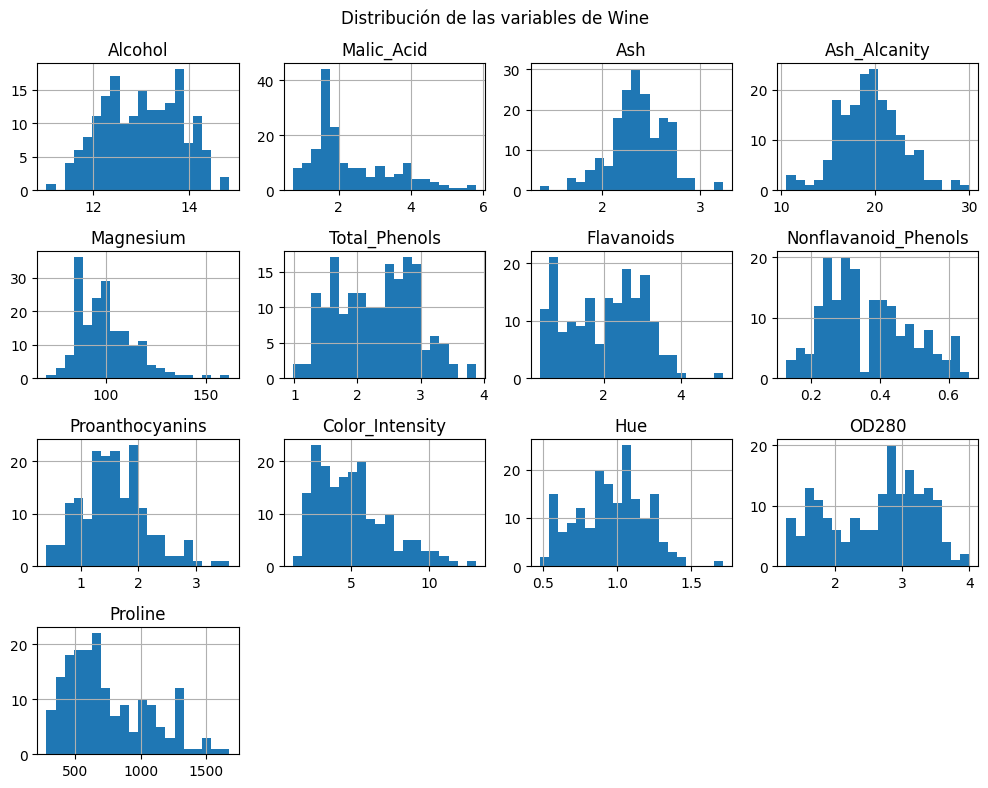

In [ ]:
df_wine.hist(figsize=(10, 8), bins=20)

plt.suptitle("Distribución de las variables de Wine", fontsize=12)
plt.tight_layout()
plt.show()

# C. Estandarizar las variables

In [ ]:
# Con el transform los valores de las variables se estandarizan a una escala:
# media = 0 y una desviación estándar = 1
# Así las variables con valores disparados quedan a escalas semejantes para comparar.

X = df_wine.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
display(X_scaled.head())

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


# E. Parámetros y Clúster Identificados con HDBSCAN

In [ ]:
#Clustering HDBSCAN
#Parámetros
clusterer = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=4, metric='euclidean')
#clusterer = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=4, metric='euclidean')
clusterer.fit(X_scaled)
labels_hds = clusterer.labels_

print("Etiquetas de los clusters HDBSCAN:")
print(labels_hds)

Etiquetas de los clusters HDBSCAN:
[ 1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1  1  1  1  1  1  1  1  1  1
  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1 -1  1  1  1  1  1  1
  1  1 -1  1  1  1  1  1  1  1  1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1
 -1 -1 -1 -1  1 -1 -1 -1  1  1  1  0 -1  1  1 -1  1  1  1  1  1  1  1 -1
 -1  1 -1 -1  1  1  1  1  1 -1  1  1  1 -1 -1  1 -1  1  1 -1  1  1 -1  1
  1 -1 -1 -1 -1  1  1 -1  1 -1 -1  0 -1 -1 -1  0 -1 -1  0  0  0  0  0  0
 -1  0 -1  0  0  0  0 -1 -1  0 -1  0  0 -1 -1 -1  0  0  0  0  0  0  0  0
  0 -1  0  0  0  0  0  0  0  0]


In [ ]:
n_clusters_hds = len(set(labels_hds)) - (1 if -1 in labels_hds else 0)
n_noise_hds = np.sum(labels_hds == -1)

print("Número de clusters por HDBSCAN:", n_clusters_hds)
print("Puntos considerados ruido:", n_noise_hds)
print("Porcentaje de ruido:", n_noise_hds / len(labels_hds) * 100)
print("\nCantidad de observaciones por cluster:")
print(pd.Series(labels_hds).value_counts().sort_index())

Número de clusters por HDBSCAN: 2
Puntos considerados ruido: 58
Porcentaje de ruido: 32.58426966292135

Cantidad de observaciones por cluster:
-1    58
 0    34
 1    86
Name: count, dtype: int64


In [ ]:
#Clustering OPTICS
#Parámetros
#optics = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05)
optics = OPTICS(min_samples=4, xi=0.05, min_cluster_size=0.05)
optics.fit(X_scaled)
labels_opt = optics.labels_
print("Etiquetas de los clusters OPTICS:")
print(labels_opt)

Etiquetas de los clusters OPTICS:
[-1 -1 -1 -1 -1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1  0  0  0  0 -1 -1 -1 -1 -1
 -1 -1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1  0  0 -1 -1 -1  0 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1  1 -1  1  1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1 -1  1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1  2  2 -1 -1 -1 -1 -1 -1 -1  2 -1 -1 -1  2 -1 -1 -1  2 -1  2  2
  2 -1 -1  2  2 -1  2 -1 -1 -1]


In [ ]:
n_clusters_opt = len(set(labels_opt)) - (1 if -1 in labels_opt else 0)
n_noise_opt = np.sum(labels_opt == -1)

print("Número de clusters por OPTICS:", n_clusters_opt)
print("Puntos considerados ruido:", n_noise_opt)
print("Porcentaje de ruido:", n_noise_opt / len(labels_opt) * 100)
print("\nCantidad de observaciones por cluster:")
print(pd.Series(labels_opt).value_counts().sort_index())

Número de clusters por OPTICS: 3
Puntos considerados ruido: 150
Porcentaje de ruido: 84.26966292134831

Cantidad de observaciones por cluster:
-1    150
 0      9
 1      8
 2     11
Name: count, dtype: int64


In [ ]:
# Identificar el cluster de cada registros
# Promedio de cada variable por cluster
df_resultado = df_wine.copy()
df_resultado["Cluster_hds"] = labels_hds
df_resultado["Cluster_opt"] = labels_opt
display(df_resultado.head())

perfil_clusters_hds = df_resultado.groupby("Cluster_hds").mean()
perfil_clusters_opt = df_resultado.groupby("Cluster_opt").mean()
display(perfil_clusters_hds)
display(perfil_clusters_opt)

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Cluster_hds,Cluster_opt
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1,-1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1,-1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1,-1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1,-1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1,-1


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Cluster_opt
Cluster_hds,,,,,,,,,,,,,,
-1,12.632931,2.364138,2.360517,20.203448,101.534483,2.252414,1.933276,0.367069,1.665862,4.530000,0.968897,2.442414,629.448276,-1.000000
0,13.249706,3.512941,2.417353,21.117647,98.147059,1.644118,0.753529,0.470882,1.116176,7.392941,0.697353,1.745294,631.470588,-0.029412
1,13.150116,1.852442,2.350465,18.375581,99.162791,2.581279,2.598372,0.315233,1.728023,4.491163,1.052558,3.068372,871.732558,-0.709302


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Cluster_hds
Cluster_opt,,,,,,,,,,,,,,
-1,12.963867,2.339067,2.365933,19.516667,100.333333,2.304400,2.056667,0.360000,1.619067,4.785533,0.966240,2.636067,732.260000,0.073333
0,13.824444,1.782222,2.596667,16.988889,109.777778,3.100000,3.274444,0.338889,1.737778,6.633333,1.098889,2.891111,1320.000000,1.000000
1,12.345000,1.493750,2.028750,19.337500,86.000000,2.036250,1.877500,0.310000,1.460000,3.000000,1.060000,3.132500,541.000000,1.000000
2,13.304545,3.365455,2.431818,21.363636,93.454545,1.698182,0.747273,0.443636,1.181818,8.982727,0.647273,1.671818,627.272727,0.000000


# E. Visualizar Clusters (Gráficas)

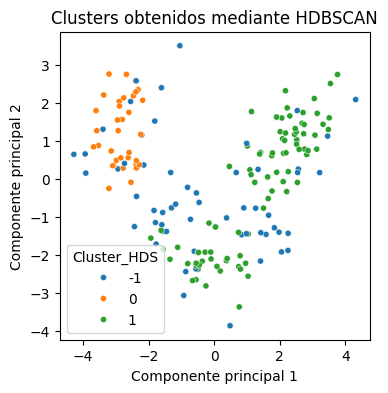

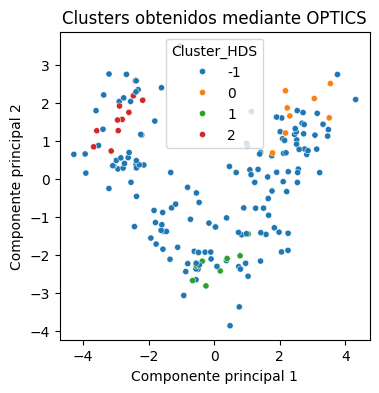

In [ ]:
#PCA para representar los resultados en dos dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_resultado["PCA1"] = X_pca[:, 0]
df_resultado["PCA2"] = X_pca[:, 1]

#Gráfica Cluster HDBSCAN
plt.figure(figsize=(4, 4))
sns.scatterplot(data=df_resultado, x="PCA1", y="PCA2", hue="Cluster_hds", palette="tab10", s=20)
plt.title("Clusters obtenidos mediante HDBSCAN")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(title="Cluster_HDS")
plt.show()

#Gráfica Cluster OPTICS
plt.figure(figsize=(4, 4))
sns.scatterplot(data=df_resultado, x="PCA1", y="PCA2", hue="Cluster_opt", palette="tab10", s=20)
plt.title("Clusters obtenidos mediante OPTICS")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend(title="Cluster_HDS")
plt.show()

# F. Calidad y Estabilidad de los Cluster

In [ ]:
# Estabilidad HDBSCAN
# identifica que el Cluster más estable es el que tiene el valor más alto
# Cluster menos estable es el que tiene el valor más bajo.
for i, estabilidad in enumerate(clusterer.cluster_persistence_):
    print(f"Estabilidad del Cluster con HDBSCAN {i}: {estabilidad:.4f}")

Estabilidad del Cluster con HDBSCAN 0: 0.0732
Estabilidad del Cluster con HDBSCAN 1: 0.1458


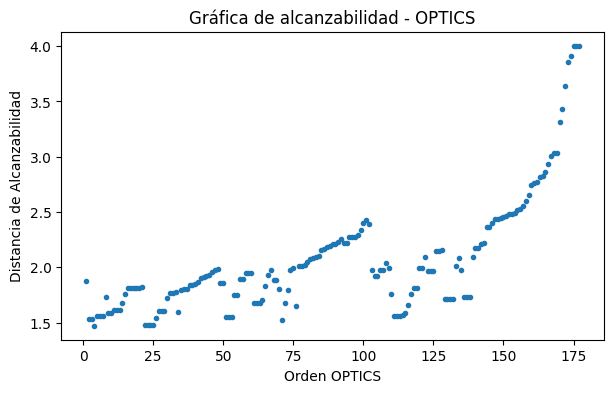

In [ ]:
#Alcanzabilidad OPTICS
space = np.arange(len(X_scaled))
reachability = optics.reachability_[optics.ordering_]
labels_ordered = optics.labels_[optics.ordering_]

plt.figure(figsize=(7, 4))
plt.plot(space, reachability, marker=".", linestyle="None" )
plt.xlabel("Orden OPTICS")
plt.ylabel("Distancia de Alcanzabilidad")
plt.title("Gráfica de alcanzabilidad - OPTICS")

plt.show()

In [ ]:
#Silhouette Score, Métrica de Calidad

#HDBSCAN
mask_hds = labels_hds != -1
labels_hds_sin = labels_hds[mask_hds]
X_hds_sin = X_scaled[mask_hds]

if len(set(labels_hds_sin)) > 1:
    silhouette_hds = silhouette_score(
        X_hds_sin,
        labels_hds_sin)
    print("Silhouette Score con HDBSCAN:", silhouette_hds)
else:
    print("Se requieren al menos 2 clusters para calcular Silhouette HDBSCAN.")

#OPTICS
mask_opt = labels_opt != -1
labels_opt_sin = labels_opt[mask_opt]
X_opt_sin = X_scaled[mask_opt]

if len(set(labels_opt_sin)) > 1:
    silhouette_opt = silhouette_score(
        X_opt_sin,
        labels_opt_sin)
    print("Silhouette Score con OPTICS:", silhouette_opt)
else:
    print("Se requieren al menos 2 clusters para calcular Silhouette OPTICS.")

Silhouette Score con HDBSCAN: 0.3524024456524659
Silhouette Score con OPTICS: 0.577718071254521


#### Calidad de Cluster HDBSCAN

| Silhouette | Interpretación              |
| ---------- | --------------------------- |
| Cerca de 1 | Clusters muy bien separados |
| 0.5 - 0.7  | Buena separación            |
| 0.25 . 0.5 | Separación moderada         |
| Cerca de 0 | Clusters poco definidos     |
| < 0        | Posible mala asignación     |


**3.-** Finalmente, interprete los resultados y redacte una conclusión argumentada sobre cuál de los dos algoritmos ofrece un mejor desempeño para este

## Resultados y Conclusión

Al aplicar los algoritmos HDBSCAN y OPTICS a los datos wine_clustering.csv se observó diferncias importantes, que se muestran en la siguiente tabla.

Con base en esos resultados, HDBSCAN presentó un mejor desempeño para este cojunto de datos, debido a que logró identifica una mayor cantidad pobervaciones agrupadas en dos cluster, presentó menor ruido y una menor separación. Obtuvo una estructura de agrupamiento más estable con los parámetros establecidos.

Parámetros

HDBSCAN: min_cluster_size=10, min_samples=4, metric='euclidean'

OPTICS: min_samples=4, xi=0.05, min_cluster_size=0.05

TABLA COMPARATIVA

| Descripción       |        HDBSCAN     |     OPTICS     |
| ----------------- | -------------------|----------------|
| Número de Cluster | 2                  | 3              |
| Punto de Ruido    | 58                 | 150            |
| % Ruido           | 32.58%             | 84.26%         |
| Cluster 0         | 34                 | 9              |
| Cluster 1         | 86                 | 8              |
| Cluster 2         | -                  | 11             |
| Silhouette        | 0.352              | 0.577          |
| Estabilidad       | 0.0732 / 0.1458    |                |

De las 178 observaciones , HDBSCAN logró agrupar 120 en dos cluster mientras que OPTICS sólo logro agrupar 28 en tres cluster. Es menor el % de ruido en HDBSCAN con 32.58% que OPTICS con 84.26%. Menciono en un ejercicio con min_samples = 5 OPTICS sólo logró agupar un solo cluster, por lo que se reajusto para realizar comparativas.

En relación a Silhouette HDBSCAN tiene menor separación que OPTICS, 0.35 < 0.57

El cluster 1 de HDBSCAN presentó mayor estabilidad que el cluster 0.
